# Feature engineering

## Load the dataset

Load the dataset processed in the previous notebook.

In [2]:
import pandas as pd

df = pd.read_csv("dataset/processed/exploratory-packages-highest-ctr.csv")

df.head()

,package_id,created_at,test_week,clickability_test_id,headline,eyecatcher_id,impressions,clicks,ctr,first_place,winner,is_highest_ctr
0,62,2014-11-20 14:57:52.478,201446,546e009a9ad54ec65b00004b,What They Learned From The Scientist Was Terri...,546c7f2dbadeb5788700000a,4594,51,0.011101,False,False,False
1,84,2014-11-20 14:54:18.78,201446,546e009a9ad54ec65b00004b,A Science Guy Helps 3 Dudes From America Under...,546c7f2dbadeb5788700000a,4571,58,0.012689,False,False,False
2,95,2014-11-20 15:04:49.517,201446,546e009a9ad54ec65b00004b,He Sat Them Down And Told Them About An Immine...,546c7f2dbadeb5788700000a,4601,27,0.005868,False,False,False
3,100,2014-11-20 15:13:36.266,201446,546e009a9ad54ec65b00004b,"The 3 Of Them Needed To See It In Person, And ...",546c7f2dbadeb5788700000a,4567,63,0.013795,True,False,True
4,102,2014-11-20 15:15:25.697,201446,546e009a9ad54ec65b00004b,"They May Not Be The Most Handsome Dudes, But T...",546c7f2dbadeb5788700000a,4524,44,0.009726,False,False,False


## Named Entity Recognition

I'll use SpaCy to extract the named entities from the headlines. I want more specifically extract if the headline mentions a person, an organization or a geographic entity.

I also verify if the headline mentions a monetary amount.

In [3]:
import spacy

print("Download spaCy model")
spacy.cli.download("en_core_web_md")
nlp = spacy.load("en_core_web_md")

Download spaCy model
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 66.8 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:

def count_named_entities(text: str) -> list:
    if not isinstance(text, str) or not text.strip():
        return []

    doc = nlp(text)

    person_names = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
    organization_names = [ent.text for ent in doc.ents if ent.label_ == "ORG"]
    geographic_names = [ent.text for ent in doc.ents if ent.label_ == "GPE"]
    monetary_amounts = [ent.text for ent in doc.ents if ent.label_ == "MONEY"]
    return len(person_names), len(organization_names), len(geographic_names), len(monetary_amounts)


# For each headline it will call the function which will return the number of persons, organizations and geographic entities identified
df[["headline_num_persons", "headline_num_orgs", "headline_num_gpes", "headline_num_moneys"]] = df["headline"].apply(lambda x: pd.Series(count_named_entities(x)))

# I also generate a boolean value
df["headline_has_person"] = df["headline_num_persons"].apply(lambda num_persons: num_persons > 0)
df["headline_has_org"] = df["headline_num_orgs"].apply(lambda num_orgs: num_orgs > 0)
df["headline_has_gpe"] = df["headline_num_gpes"].apply(lambda num_gpes: num_gpes > 0)
df["headline_has_money"] = df["headline_num_moneys"].apply(lambda num_moneys: num_moneys > 0)
df = df.drop(columns=["headline_num_moneys"])

df[["headline", "headline_num_persons", "headline_num_orgs", "headline_num_gpes", "headline_has_person", "headline_has_org", "headline_has_gpe", "headline_has_money"]].head()


,headline,headline_num_persons,headline_num_orgs,headline_num_gpes,headline_has_person,headline_has_org,headline_has_gpe,headline_has_money
0,What They Learned From The Scientist Was Terri...,0,0,0,False,False,False,False
1,A Science Guy Helps 3 Dudes From America Under...,0,0,1,False,False,True,False
2,He Sat Them Down And Told Them About An Immine...,0,0,1,False,False,True,False
3,"The 3 Of Them Needed To See It In Person, And ...",0,0,0,False,False,False,False
4,"They May Not Be The Most Handsome Dudes, But T...",0,0,0,False,False,False,False


### Famous people mentioned in the headline

I obtained this idea from the Nate Matias meta analysis and a proposal made in his course:

[Github - Lecture 15 - Asking Questions of the Upworthy Archive](https://github.com/natematias/design-governance-experiments/blob/master/2020/lectures/Lecture%2015%20-%20Asking%20Questions%20of%20the%20Upworthy%20Archive.pdf)

First I'll extract and print the names of persons identified in the headlines.

In [7]:
def get_persons(text: str) -> list:
    if not isinstance(text, str) or not text.strip():
        return []
    doc = nlp(text)
    person_names = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
    return person_names

# Combine all person names from all headlines into one list
person_names = set()
for persons in df["headline"].apply(get_persons):
    person_names.update(persons)

print(f"{len(person_names)} unique persons found in the headlines")

print(f"Persons found: {', '.join(person_names)}")


673 unique persons found in the headlines
Persons found: Jennifer Aniston, Zombie Brains, Abraham Lincoln, Eating Healthy Is Challenging As, This Guy Talked Back, Rosario Dawson, James Bond, George Lopez, Stormie, Dan Quayle, L.O.V.E., Bullshit, Huggles Required, These Black Girls Are Coming For Your Throne, Introvert, This Guy, Janay Rice Ought, Hitler, Sam Pepper Lost A Lot Over His Sexual Assault 'Antics, Moms Rock, This Innocent Teen Finally Gets To, Newly Married, Beyonce, Argumentative Guy, Mary Poppins Impression, Leonardo DiCaprio, Renegade Bees, Mighty Thirsty, Beyoncé Be, Samuel L. Jackson Just, Glen Close, Joan Rivers Paved The Way For Countless Female Comics While Making Everyone Laugh, Bob Dylan, Angelina Jolie, Tess Munster, Steven Spielberg X, Obama, Thomas Jefferson, Hank Green Goes Up Against A Corporate Suit To Debate An Unsexy, Obama Shames, Adrian Peterson, Billy Joel, The Simple Brilliance Of His Idea Is Sweet, Lesbians, Soooo, Teen Nails, Rams, Iggy Azalea, Marvin

In [8]:
print("Persons found:")
for name in person_names:
    print(name)

Persons found:
Jennifer Aniston
Zombie Brains
Abraham Lincoln
Eating Healthy Is Challenging As
This Guy Talked Back
Rosario Dawson
James Bond
George Lopez
Stormie
Dan Quayle
L.O.V.E.
Bullshit
Huggles Required
These Black Girls Are Coming For Your Throne
Introvert
This Guy
Janay Rice Ought
Hitler
Sam Pepper Lost A Lot Over His Sexual Assault 'Antics
Moms Rock
This Innocent Teen Finally Gets To
Newly Married
Beyonce
Argumentative Guy
Mary Poppins Impression
Leonardo DiCaprio
Renegade Bees
Mighty Thirsty
Beyoncé Be
Samuel L. Jackson Just
Glen Close
Joan Rivers Paved The Way For Countless Female Comics While Making Everyone Laugh
Bob Dylan
Angelina Jolie
Tess Munster
Steven Spielberg X
Obama
Thomas Jefferson
Hank Green Goes Up Against A Corporate Suit To Debate An Unsexy
Obama Shames
Adrian Peterson
Billy Joel
The Simple Brilliance Of His Idea Is Sweet
Lesbians
Soooo
Teen Nails
Rams
Iggy Azalea
Marvin Gardens
Burns
Jim Carrey's
Tries
Adorbs
Swapping Wheelchairs
Monica Lewinsky
Threatened H

I was planning to verify if the persons found are famous by going to Wikipedia, but doing a quick review I see almost every name identified is already a famous person.

In many cases, segments of words are identified as persons, like "Eating Healthy Is Challenging As", but the number of those errors is very low.

### Review results

<Axes: >

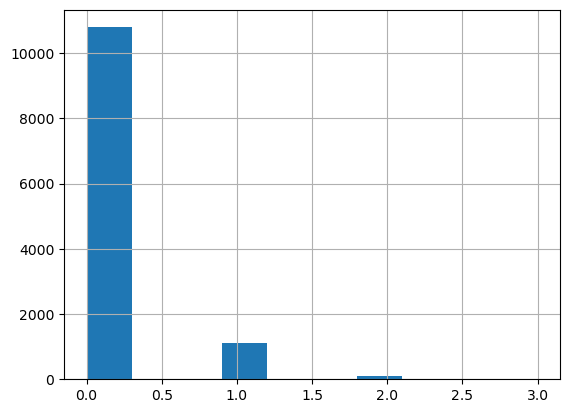

In [12]:
df["headline_num_persons"].hist()

<Axes: >

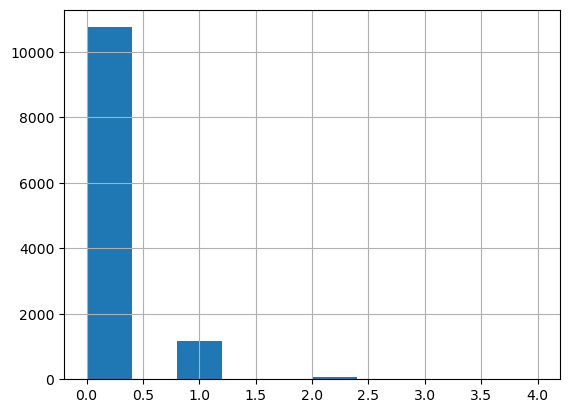

In [13]:
df["headline_num_orgs"].hist()

<Axes: >

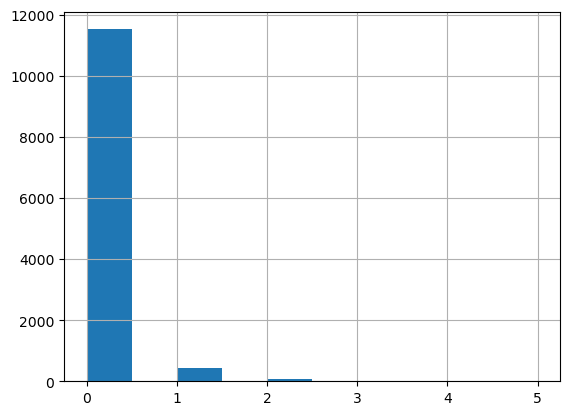

In [14]:
df["headline_num_gpes"].hist()

In [20]:
print(df["headline_has_person"].value_counts())
print(df["headline_has_org"].value_counts())
print(df["headline_has_gpe"].value_counts())
print(df["headline_has_money"].value_counts())

headline_has_person
False    10796
True      1214
Name: count, dtype: int64
headline_has_org
False    10749
True      1261
Name: count, dtype: int64
headline_has_gpe
False    11522
True       488
Name: count, dtype: int64
headline_has_money
False    11935
True        75
Name: count, dtype: int64


## Other features

I'll also extract some simple features that may be useful for the prediction:
- starts_with_verb
- starts_with_pronoun
- starts_with_number
- num_pronouns
- num_chars
- num_tokens
- avg_token_len
- ends_with_qmark
- ends_with_exclaim
- has_quote
- has_all_caps_word
- num_nouns
- num_verbs
- num_adjs
- num_advs
- num_pronouns

At worst they won't hurt.

In [21]:
import numpy as np

def extract_spacy_features(text: str) -> pd.Series:
    doc = nlp(text)

    # Tokenize
    tokens = [t for t in doc if not t.is_space]
    content_tokens = [t for t in tokens if not t.is_punct]
    first_token = content_tokens[0] if content_tokens else None

    # First token is a verb or an auxiliary
    starts_with_verb = (first_token is not None and first_token.pos_ in ("VERB", "AUX"))
    # First token is a pronoun
    starts_with_pronoun = first_token is not None and first_token.pos_ == "PRON"
    # First token is a number
    starts_with_number = (first_token is not None and (first_token.like_num or first_token.pos_ == "NUM"))

    # Calculate length
    num_chars = len(text)
    num_tokens = len(tokens)
    if num_tokens > 0:
        avg_token_len = (float(sum(len(t.text) for t in tokens)) / num_tokens)
    else:
        avg_token_len = 0.0

    # Get if the headline ends with a question or an exclamation mark
    stripped = text.rstrip()
    ends_with_qmark = stripped.endswith("?")
    ends_with_exclaim = stripped.endswith("!")

    # Get if the headline contains a quote
    quote_chars = ['"', "'", "“", "”", "‘", "’"]
    has_quote = any(ch in text for ch in quote_chars)

    # Has an all-caps word or acronym
    # is_alpha checks if the token is alphabetic
    has_all_caps_word = any(tok.is_alpha and tok.text.isupper() and len(tok.text) > 1 for tok in tokens)

    # Other features obtained from POS tagging
    num_nouns = sum(t.pos_ in ("NOUN", "PROPN") for t in tokens)
    num_verbs = sum(t.pos_ in ("VERB", "AUX") for t in tokens)
    num_adjs = sum(t.pos_ == "ADJ" for t in tokens)
    num_advs = sum(t.pos_ == "ADV" for t in tokens)
    num_pronouns = sum(t.pos_ == "PRON" for t in tokens)

    return pd.Series(
        {
            "starts_with_verb": starts_with_verb,
            "starts_with_pronoun": starts_with_pronoun,
            "starts_with_number": starts_with_number,
            "num_pronouns": num_pronouns,
            "num_chars": num_chars,
            "num_tokens": num_tokens,
            "avg_token_len": avg_token_len,
            "ends_with_qmark": ends_with_qmark,
            "ends_with_exclaim": ends_with_exclaim,
            "has_quote": has_quote,
            "has_all_caps_word": has_all_caps_word,
            "num_nouns": num_nouns,
            "num_verbs": num_verbs,
            "num_adjs": num_adjs,
            "num_advs": num_advs,
        }
    )


features = df["headline"].apply(extract_spacy_features)
df = pd.concat([df, features], axis=1)

df[[
    "headline",
    "starts_with_verb",
    "starts_with_pronoun",
    "starts_with_number",
    "num_pronouns",
    "num_chars",
    "num_tokens",
    "avg_token_len",
    "ends_with_qmark",
    "ends_with_exclaim",
    "has_quote",
    "has_all_caps_word",
    "num_nouns",
    "num_verbs",
    "num_adjs",
    "num_advs",
]].head()

,headline,starts_with_verb,starts_with_pronoun,starts_with_number,num_pronouns,num_chars,num_tokens,avg_token_len,ends_with_qmark,ends_with_exclaim,has_quote,has_all_caps_word,num_nouns,num_verbs,num_adjs,num_advs
0,What They Learned From The Scientist Was Terri...,False,True,False,5,89,18,4.166667,False,False,True,False,2,5,0,0
1,A Science Guy Helps 3 Dudes From America Under...,False,False,False,2,82,15,4.600000,False,False,True,False,5,2,0,1
2,He Sat Them Down And Told Them About An Immine...,False,True,False,5,92,19,3.894737,False,False,False,False,3,4,0,1
3,"The 3 Of Them Needed To See It In Person, And ...",False,False,False,4,95,22,3.409091,False,False,False,False,2,4,2,1
4,"They May Not Be The Most Handsome Dudes, But T...",False,True,False,3,89,20,3.700000,False,False,True,False,2,4,2,1


## Sentence Structure Analysis

### Identify if the sentence has an imperative style

In [28]:
def has_imperative_style(text: str) -> list:
    doc = nlp(text)

    # Get the root of the sentence
    roots = [t for t in doc if t.dep_ == "ROOT"]
    has_imperative = False
    for root in roots:
        if root.pos_ == "VERB":
            # If the verb is in simple tense
            if root.tag_ == "VB":
                # If no subject token has this verb as the dependency
                if not any(t.head == root and t.dep_ in ["nsubj", "nsubjpass", "csubj"] for t in doc):
                    print(root.text, end=", ")
                    return True
    return False


df["headline_imperative_verb"] = df["headline"].apply(lambda x: pd.Series(has_imperative_style(x)))

Allow, Avoid, Meet, Give, Feel, Let, Look, See, Guess, Watch, Meet, Guess, Watch, Ask, Hear, Hear, Say, Forget, Watch, Find, Fast, See, Check, Let, Buy, Save, Meet, See, Get, Fire, Guess, Tell, Listen, Call, Move, Watch, Ask, Let, Watch, See, Watch, Remember, Know, Need, Look, Love, Call, Let, Get, Find, Hear, Lovin', Watch, Take, talk, Let, Watch, Listen, Put, Stop, Take, quiz, Go, Think, Listen, Listen, Listen, Take, Meet, See, Watch, Remember, fly, miss, Want, Imagine, Let, See, Let, Watch, Watch, Look, Meet, Bet, Want, Hear, See, Imagine, Let, help, Let, Imagine, Listen, Listen, Cute, Find, Ask, Ask, Ask, Ask, Ask, See, Wonder, Listen, Tell, Tell, Watch, Watch, Watch, Come, Let, Realize, Let, Check, Hear, Hear, Look, See, Have, Bet, Forget, Meet, Take, Panic, WATCH, Look, Take, Go, Let, Think, See, Stop, Make, Let, Let, Walk, Watch, Tell, Explain, Explain, Explain, Explain, Explain, Explain, Explain, Watch, Watch, Watch, Look, Ask, Have, Hear, Hear, Meet, Hear, Watch, Think, Guess,

In [29]:
print(df["headline_imperative_verb"].value_counts())

headline_imperative_verb
False    10649
True      1361
Name: count, dtype: int64


I tried to use SpaCy "mood" attribute which should return "Imp" if it detects an imperative sentence, but it didn't find it for any of the sentences.

## Sentiment Analysis

## Dataset related features



In [37]:
df["created_at"] = pd.to_datetime(df["created_at"], format="mixed")

# Day of the week
df["created_at_dayofweek"] = df["created_at"].dt.dayofweek

# Hour of the day
df["created_at_hourofday"] = df["created_at"].dt.hour

Each test has a number of packages, could be 2, 3, 4, etc. A given package is competing with the other packages in the test. This will be important to calculate the probability of winning the competition in a random scenario.

I'll add to each package the number of other packages in the test.




In [38]:
df["test_group_size"] = df.groupby("clickability_test_id")["clickability_test_id"].transform("size")

In [45]:
df[["clickability_test_id", "test_group_size"]][:20]

,clickability_test_id,test_group_size
0,546e009a9ad54ec65b00004b,6
1,546e009a9ad54ec65b00004b,6
2,546e009a9ad54ec65b00004b,6
3,546e009a9ad54ec65b00004b,6
4,546e009a9ad54ec65b00004b,6
5,546cb9c954524053ac000013,4
6,546cb9c954524053ac000013,4
7,546cb9c954524053ac000013,4
8,546e454a9ad54e2af0000070,6
9,54d1967c63666200191c0000,6
